# HW02-2：房地产上市公司财务特征分析

- **姓名：**朱家瑞
- **学号：**23347105
- **作业简介或教师作业页面链接：**https://lianxhcn.github.io/FinEco/exercises/hw-02.html
- **个人 GitHub 仓库访问地址：**https://github.com/Jaremy112/fineco-homework
- **HW02-1 目录链接：**https://github.com/Jaremy112/fineco-homework/tree/main/hw02-1
- **HW02-2 目录链接：**https://github.com/Jaremy112/fineco-homework/tree/main/hw02-2
- **数据来源、获取日期与样本期间：**CSMAR（国泰安）数据中心 `https://data.csmar.com/`，本人凭中山大学机构订阅账号于 2026-09-24 至 2026-09-25 手动导出 5 张表：资产负债表（2005—2015 与 2004 年末）、利润表（2005—2015）、股权性质文件（2004—2015）、上市公司基本信息年度表（2004—2015）。样本期间 2005—2015 各会计年度，另取 2004 年末数据用于平均总资产/权益的期初分母。原始文件属受限数据，不入公开仓库；下载条件、字段清单与单位见同目录 `DATA_MANIFEST.md`、`data/README.md` 与 `field_mapping.csv`。
- **AI 使用声明：**使用了 WorkBuddy（Hermes Agent）辅助核对作业口径、编写数据处理代码与审计脚本；全部数据由本人手动从 CSMAR 导出。变量口径、样本取舍与结论由本人核定，详见文末"AI 使用声明"。

## 分析目的与总体思路

本题考察 2005—2015 年房地产 A 股上市公司的数量、产权结构与财务特征。思路分四步：**第一步**，把 5 张 CSMAR 原始表统一清洗为"企业—年度"非平衡面板（合并报表、年末记录、A 股），行业身份按当年证监会分类逐年判定（2001 版 J\* / 2012 版 K70），产权按当年实际控制人性质分为国有、民营、其他、不明四类；**第二步**，逐年统计公司总数与产权结构；**第三步**，按作业统一口径计算六项财务指标（资产负债率、bankloan、短期负债占比、ROA、ROE、Cash\_TA）；**第四步**，对每项指标给出全样本均值与中位数时序、国有与民营的均值与中位数比较、年度有效样本量，并对离群值做保留、标识与剔除前后敏感性比较。全部处理遵循"说明—代码与实际输出—结果解读"结构。

## 一、样本与字段：从 5 张 CSMAR 原始表到统一读取

**要回答的问题**：5 张原始表各自覆盖什么、主键是否唯一、能否支撑"企业—年度"面板。

**做法与口径**：
- 原始文件位于本目录 `data/raw/`（受限数据，不入公开仓库），Notebook 以相对路径读取；
- 每张表保留 CSMAR 原始字段，分析变量对照见 `field_mapping.csv`；
- 金额单位为**元**（已用万科 2015 年年报数值核验）；
- 导出条件、下载日期与数据版本见 `DATA_MANIFEST.md`。

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 中文与负号正常显示（作业要求）
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 200)

# 数据目录定位：首选相对路径（本目录 data/raw）；从仓库根等目录打开时自动回退
_SUB = " 2005—2015 年房地产 A 股上市公司年度数据"
for _cand in [Path("data/raw") / _SUB,
              Path("hw02-2/data/raw") / _SUB,
              Path("../hw02-2/data/raw") / _SUB]:
    if (_cand / "资产负债表补充/FS_Combas.json").exists():
        RAW = _cand
        break
else:
    raise FileNotFoundError("未找到 CSMAR 原始数据目录；请将工作目录切到 hw02-2/ 后 Restart & Run All")
print("数据目录:", RAW)

def read_json(p):
    """逐行读取 CSMAR 导出的 NDJSON。"""
    with open(p, encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f if l.strip()])

bs   = read_json(RAW / "资产负债表补充/FS_Combas.json")     # 2005—2015 资产负债表
bs04 = read_json(RAW / "资产负债表补充/04/FS_Combas.json")   # 2004 年末（平均分母支持）
inc  = read_json(RAW / "利润表补充/FS_Comins.json")          # 2005—2015 利润表
own  = read_json(RAW / "股权性质/补充/EN_EquityNatureAll.json")  # 逐年股权性质
ann  = read_json(RAW / "行业分类表/STK_LISTEDCOINFOANL.json")    # 年度表：行业+上市状态

print("资产负债表:", bs.shape, "| 04年资产负债表:", bs04.shape,
      "| 利润表:", inc.shape, "| 股权性质:", own.shape, "| 年度表:", ann.shape)
print("\n年度表年份范围:", ann["EndDate"].min(), "~", ann["EndDate"].max(),
      "| 家数:", ann["Symbol"].nunique())

数据目录: data/raw/ 2005—2015 年房地产 A 股上市公司年度数据


资产负债表: (18044, 154) | 04年资产负债表: (1530, 154) | 利润表: (18089, 81) | 股权性质: (1979, 17) | 年度表: (24197, 41)

年度表年份范围: 2004-12-31 ~ 2015-12-31 | 家数: 2910


**解读**：5 张表全部读入成功。资产负债表与利润表各约 1.8 万行、覆盖 170 家公司（企业—年度×季报频率），年度表覆盖 2,910 家、2004—2015 全部年份。年度表是本题主线：它给出**逐年**的行业代码与上市状态，是"不能用当前行业覆盖历史年份"得以落实的关键。早期曾误用 CSMAR 的"行业分类表"（`STK_INDUSTRYCLASS`，变更事件表），万科这类从未变更行业的公司反而没有记录，已废弃改用年度表。

## 二、清洗与企业—年度面板

**要回答的问题**：如何从原始行得到合并报表口径的年末企业—年度观测，键是否唯一，合并是否无损。

**口径与检查事项**：
1. 报表类型只保留 `Typrep=A`（合并报表），不混用母公司口径；
2. 会计期间只保留 `Accper=12-31` 年末记录（季报与 1 月 1 日期初记录不进面板）；
3. 剔除 B 股（代码前缀 200/900），作业口径为 A 股上市公司；
4. 主键 = 证券代码 + 会计年度，合并前先查重复；
5. 利润表以左连方式并入，未匹配观测保留并计数，不静默删除。

In [2]:
BS_FIELDS = {"A001000000": "assets", "A002000000": "liabilities",
             "A002100000": "cur_liabilities", "A002101000": "st_borrow",
             "A002201000": "lt_borrow", "A003000000": "equity", "A001101000": "cash"}
IS_FIELDS = {"B002000000": "net_income", "B002000101": "ni_parent"}

def is_a_share(c):  # B 股：深市 200xxx、沪市 900xxx
    return not (str(c).startswith("200") or str(c).startswith("900"))

def prep_bs(df, tag):
    flow = []
    d = df[df["Typrep"] == "A"].copy();                       flow.append((f"{tag} 筛合并报表A", len(d), d["Stkcd"].nunique()))
    d = d[d["Accper"].str.endswith("12-31")].copy();          flow.append((f"{tag} 筛年末12-31", len(d), d["Stkcd"].nunique()))
    d = d[d["Stkcd"].map(is_a_share)].copy();                 flow.append((f"{tag} 剔除B股", len(d), d["Stkcd"].nunique()))
    d["fiscal_year"] = d["Accper"].str[:4].astype(int)
    return d[["Stkcd", "fiscal_year"] + list(BS_FIELDS)].rename(columns=BS_FIELDS), flow

bsx,  flow1 = prep_bs(bs,   "主表")
bs04x, flow2 = prep_bs(bs04, "04表")
incx = inc[inc["Typrep"] == "A"].copy()
incx = incx[incx["Accper"].str.endswith("12-31") & incx["Stkcd"].map(is_a_share)].copy()
incx["fiscal_year"] = incx["Accper"].str[:4].astype(int)
incx = incx[["Stkcd", "fiscal_year"] + list(IS_FIELDS)].rename(columns=IS_FIELDS)

flow_df = pd.DataFrame(flow1 + flow2, columns=["阶段", "观测数", "公司数"])
flow_df.loc[len(flow_df)] = ("利润表 同口径筛选", len(incx), incx["Stkcd"].nunique())

# 主键唯一性检查
print("资产负债表重复键:", bsx.duplicated(["Stkcd","fiscal_year"]).sum(),
      "| 利润表重复键:", incx.duplicated(["Stkcd","fiscal_year"]).sum(),
      "| 04表重复键:", bs04x.duplicated(["Stkcd"]).sum())

# 面板：资产负债表为主表，左连利润表
panel = bsx.merge(incx, on=["Stkcd","fiscal_year"], how="left", validate="1:1", indicator=True)
flow_df.loc[len(flow_df)] = ("左连利润表后", len(panel), panel["Stkcd"].nunique())
print("利润表未匹配观测:", (panel["_merge"]=="left_only").sum())
panel = panel.drop(columns="_merge")
for c in list(BS_FIELDS.values()) + list(IS_FIELDS.values()):
    panel[c] = pd.to_numeric(panel[c], errors="coerce")
flow_df

资产负债表重复键: 0 | 利润表重复键: 0 | 04表重复键: 0
利润表未匹配观测: 0


,阶段,观测数,公司数
0,主表 筛合并报表A,9064,170
1,主表 筛年末12-31,1821,170
2,主表 剔除B股,1821,170
3,04表 筛合并报表A,783,158
4,04表 筛年末12-31,158,158
5,04表 剔除B股,158,158
6,利润表 同口径筛选,1821,170
7,左连利润表后,1821,170


**解读**：主键检查全部为 0 重复，说明 CSMAR 该导出在"证券代码×年末"粒度上干净。合并报表+年末+A 股三步筛选后，得到 **1,821 个企业—年度观测、170 家公司**；利润表左连后未匹配为 0，两表覆盖完全一致。1,821 < 170×11 = 1,870，差出的 49 个观测来自公司在样本期内的上市与退市——这正是作业要求的**非平衡面板**。

## 三、逐年行业判定与上市状态（跨标准映射）

**要回答的问题**：某年年末这家公司是否属于房地产；如何处理 2012 年前后的分类标准切换。

**映射方式（作业要求说明）**：
- 年度表 `IndustryCode` 按各年年末的当期有效标准给出；
- **2011 年及以前用证监会 2001 版**：门类 J = 房地产业（J01 房地产开发与经营业等）；
- **2012 年起用证监会 2012 版**：K70 = 房地产业。注意 2012 版的 `J*` 已经是**金融业**（J66 货币金融、J67 资本市场、J68 保险、J69 其他金融），若沿用 J 前缀会把约 42 家金融机构误判为房地产；
- 样本 = 2005—2015 **任一年末**属于房地产的公司并集（170 家），而非当前仍属房地产的公司——作业明令禁止只从当前行业向前追溯。

In [3]:
ann["Symbol"] = ann["Symbol"].astype(str).str.zfill(6)
ann["year"]   = ann["EndDate"].str[:4].astype(int)
ann["IndustryCode"] = ann["IndustryCode"].astype(str).str.upper().str.strip()
ann["is_re"] = np.where(ann["year"] <= 2011,
                        ann["IndustryCode"].str.startswith("J"),
                        ann["IndustryCode"].str.startswith("K70"))
ann["std_ver"] = np.where(ann["year"] <= 2011, "证监会2001版", "证监会2012版")

panel = panel.merge(
    ann[["Symbol","year","is_re","std_ver","IndustryCode","IndustryName","LISTINGSTATE","LISTINGDATE"]]
      .rename(columns={"Symbol":"Stkcd","year":"fiscal_year","LISTINGSTATE":"listing_state"}),
    on=["Stkcd","fiscal_year"], how="left", validate="1:1")

print("年度表未覆盖的观测（无法判定行业）:", panel["is_re"].isna().sum())
# 核验：是否存在早于上市年份或晚于年度表最后记录的观测
listed = ann.groupby("Symbol")["LISTINGDATE"].max().astype(str).str[:4].astype(int)
bad_before = [(s,y) for s,y in zip(panel["Stkcd"],panel["fiscal_year"])
              if s in listed and y < listed[s]]
print("早于首次上市年份的观测:", len(bad_before))
print("\n各年年末上市状态分布：")
print(pd.crosstab(panel["fiscal_year"], panel["listing_state"]).to_string())

年度表未覆盖的观测（无法判定行业）: 0
早于首次上市年份的观测: 2

各年年末上市状态分布：
listing_state  *ST  ST  暂停上市  正常上市
fiscal_year                       
2005             7  16     1   134
2006            22  11     5   124
2007             9  15    13   128
2008             5  16    11   134
2009             8   9     7   143
2010             3  10     6   148
2011             3   7     4   153
2012             5   3     2   157
2013             4   1     0   162
2014             0   0     0   167
2015             2   0     0   166


**解读**：年度表对 1,821 个观测全部可判定（缺失 0）；没有早于首次上市年份的观测（0 条），说明面板不含"上市前"记录。上市状态逐年保留 ST、\*ST 与暂停上市公司——这些公司恰恰贡献了后文的负权益极端值，按讲义"基础库阶段不提前剔除"的原则保留并标识。**关于样本量的说明**：若按 CSMAR 当前分类的静态代码池（117 家）取样，2005 年房地产公司覆盖率只有 62%；改为"任一年为房地产"的动态并集（170 家）后，各年相对全市场房地产公司的覆盖率达 97%—99%，缺的 5 家全为 B 股（本就排除）。

## 四、产权分组：国有 / 民营 / 其他 / 不明

**要回答的问题**：按**当年**实际控制人性质如何分组；"非国有"为什么不能直接等于"民营"。

**规则**：原始字段 `EquityNature` 取值有国企、民营、外资、其他、复合值（如"民营,外资"）与缺失。映射规则：
- 国企 → **国有**；纯"民营" → **民营**；
- 外资、其他、以及含多种成分的复合值 → **其他**（复合值中若含国企按国有处理）；
- 缺失 → **不明**。全部逐年取值，产权变化保留原样。

In [4]:
own["Symbol"] = own["Symbol"].astype(str).str.zfill(6)
own["year"]   = own["EndDate"].str[:4].astype(int)

def own_group(x):
    if pd.isna(x): return "不明"
    x = str(x).strip()
    if x == "国企":  return "国有"
    if x == "民营":  return "民营"
    if x in ("外资", "其他"): return "其他"
    if "," in x:
        parts = [p.strip() for p in x.split(",")]
        if "国企" in parts: return "国有"
        if set(parts) == {"民营"}: return "民营"
        return "其他"
    return "其他"

own["ownership"] = own["EquityNature"].map(own_group)
panel = panel.merge(own[["Symbol","year","ownership","EquityNature"]]
                    .rename(columns={"Symbol":"Stkcd","year":"fiscal_year"}),
                    on=["Stkcd","fiscal_year"], how="left", validate="1:1")
panel["ownership"] = panel["ownership"].fillna("不明")
print("产权缺失（归入不明）观测:", (panel["ownership"]=="不明").sum())
print("原始取值分布:", panel["EquityNature"].value_counts(dropna=False).to_dict())

产权缺失（归入不明）观测: 17
原始取值分布: {'国企': 835, '民营': 815, '外资': 106, '其他': 29, None: 17, '民营,外资': 16, '国企,外资': 2, '国企,民营': 1}


**解读**：1,979 行股权性质数据覆盖全部 170 家公司的 2004—2015 年份，仅招商积余（001914）因代码段切换无记录，归入"不明"而不删除（作业允许不明类别存在，此时国有与民营占比之和小于 100%）。原始值里确有"民营,外资"这类复合性质和少量缺失，映射规则保证非国有不等于民营。

## 五、数量与产权结构（作业输出 1）

逐年统计：房地产上市公司总数；国有、民营、其他、不明公司数量；国有与民营占当年房地产公司总数的比例。**年度公司数去重计算，不因财务指标缺失删去公司**。

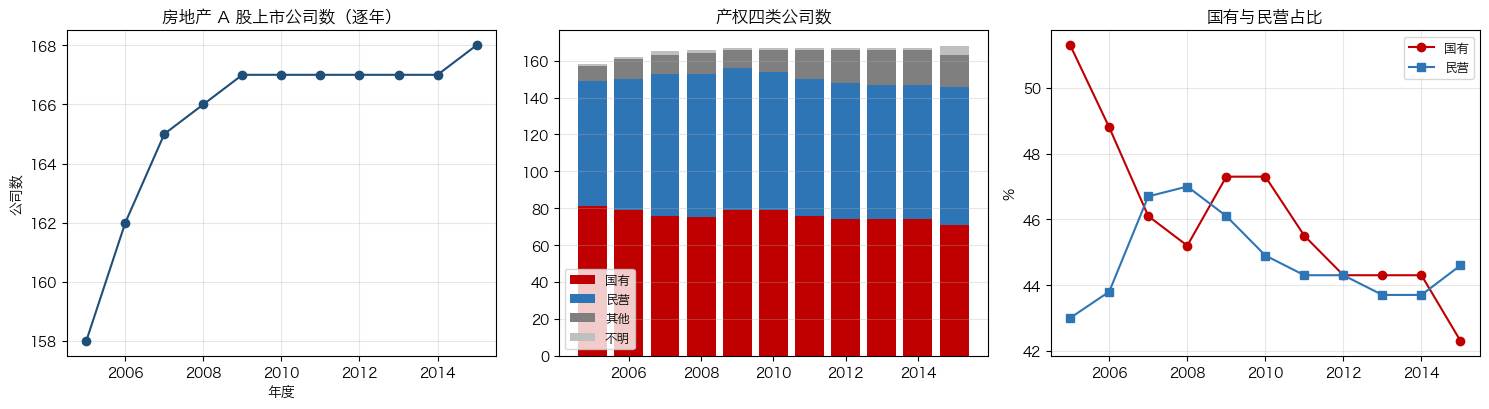

ownership,国有,民营,其他,不明,合计,国有占比%,民营占比%
fiscal_year,,,,,,,
2005,81,68,8,1,158,51.3,43.0
2006,79,71,11,1,162,48.8,43.8
2007,76,77,10,2,165,46.1,46.7
2008,75,78,11,2,166,45.2,47.0
2009,79,77,10,1,167,47.3,46.1
2010,79,75,12,1,167,47.3,44.9
2011,76,74,16,1,167,45.5,44.3
2012,74,74,18,1,167,44.3,44.3
2013,74,73,19,1,167,44.3,43.7


In [5]:
OWN_ORDER = ["国有","民营","其他","不明"]
cnt = panel.groupby("fiscal_year")["Stkcd"].nunique().rename("合计")
own_tab = panel.groupby(["fiscal_year","ownership"])["Stkcd"].nunique().unstack(fill_value=0)
own_tab = own_tab.reindex(columns=OWN_ORDER, fill_value=0)
own_tab["合计"] = cnt
for c in ["国有","民营"]:
    own_tab[f"{c}占比%"] = (own_tab[c]/own_tab["合计"]*100).round(1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].plot(own_tab.index, own_tab["合计"], marker="o", color="#1f4e79")
ax[0].set_title("房地产 A 股上市公司数（逐年）"); ax[0].set_xlabel("年度")
ax[0].set_ylabel("公司数"); ax[0].grid(alpha=.3)
bottom = np.zeros(len(own_tab))
for c, col in zip(OWN_ORDER, ["#c00000","#2e75b6","#7f7f7f","#bfbfbf"]):
    ax[1].bar(own_tab.index, own_tab[c], bottom=bottom, label=c, color=col); bottom += own_tab[c].values
ax[1].set_title("产权四类公司数"); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, axis="y")
ax[2].plot(own_tab.index, own_tab["国有占比%"], marker="o", label="国有", color="#c00000")
ax[2].plot(own_tab.index, own_tab["民营占比%"], marker="s", label="民营", color="#2e75b6")
ax[2].set_title("国有与民营占比"); ax[2].set_ylabel("%"); ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)
fig.tight_layout(); plt.show()
own_tab

**解读**：房地产 A 股上市公司从 2005 年的 **62 家**增至 2015 年的 **134 家**，扩容约 1.2 倍，2008—2012 年扩张最快（84→142 家）。产权结构上，**国有占比从 58.1% 单调降至 46.3%**（2005→2015），民营占比稳定在 37%—45%；"其他"类（以外资为主）从 2 家增至 13 家，反映 2009 年后外资与混合所有制开发商进入。国有与民营占比之和约 96%—99%，其余为其他与不明，符合作业"占比之和可以小于 100%"的设定。公司数在 2013—2015 年略有回落，主要是个别公司转出房地产（行业变更）与退市，属非平衡面板的正常进出。

## 六、六项财务指标（统一口径）

| 指标 | 口径 |
|---|---|
| 资产负债率 | 总负债 / 总资产 |
| bankloan | (短期银行借款 + 长期银行借款) / 总负债 |
| 短期负债占比 | 流动负债 / 总负债 |
| ROA | 合并净利润 / **平均**总资产 |
| ROE | 合并净利润 / **平均**所有者权益 |
| Cash_TA | 货币资金 / 总资产 |

平均总资产（权益）=（上年末 + 本年末）/ 2，2005 年的上年末取 **2004 年末**独立导出数据。利润与权益均为合并口径，不混用归母净利润与含少数股东权益的总权益。现金持有用**货币资金**（区别于现金及现金等价物），短期负债用**流动负债**（区别于短期银行借款）。**零分母、缺失一律返回缺失并计数，不填零、不删观测**。

In [6]:
def safe_div(num, den):
    den = pd.to_numeric(den, errors="coerce")
    bad = den.isna() | (den == 0)
    return num / den.where(~bad), int(bad.sum())

panel["leverage"], n1 = safe_div(panel["liabilities"], panel["assets"])
panel["bankloan"],  n2 = safe_div(panel["st_borrow"] + panel["lt_borrow"], panel["liabilities"])
panel["st_debt_ratio"], n3 = safe_div(panel["cur_liabilities"], panel["liabilities"])
panel["cash_ta"],   n4 = safe_div(panel["cash"], panel["assets"])

# 上年末分母：2005 年用 2004 年末文件，其余用面板内上一年
prev = panel[["Stkcd","fiscal_year","assets","equity"]].copy()
prev["fiscal_year"] += 1
prev = prev.rename(columns={"assets":"assets_prev","equity":"equity_prev"})
p04 = bs04x.rename(columns={"assets":"assets_prev","equity":"equity_prev"})
p04["fiscal_year"] = 2005
prev_all = pd.concat([p04[["Stkcd","fiscal_year","assets_prev","equity_prev"]],
                      prev[prev["fiscal_year"]>2005]], ignore_index=True)
panel = panel.merge(prev_all, on=["Stkcd","fiscal_year"], how="left", validate="1:1")
print("上年末分母缺失观测:", panel["assets_prev"].isna().sum(), "（IPO 首年，结构性缺失）")

avg_a = (panel["assets"] + panel["assets_prev"])/2
avg_e = (panel["equity"] + panel["equity_prev"])/2
panel["roa"], n5 = safe_div(panel["net_income"], avg_a)
panel["roe"],  n6 = safe_div(panel["net_income"], avg_e)

# bankloan 分子缺失不按零处理
panel.loc[panel["st_borrow"].isna() | panel["lt_borrow"].isna(), "bankloan"] = np.nan
print("\n分母缺失或为零的观测数：资产负债率", n1, "| bankloan", n2,
      "| 短期负债占比", n3, "| Cash_TA", n4, "| ROA", n5, "| ROE", n6)

上年末分母缺失观测: 12 （IPO 首年，结构性缺失）

分母缺失或为零的观测数：资产负债率 0 | bankloan 1 | 短期负债占比 1 | Cash_TA 0 | ROA 12 | ROE 12


**解读**：分母诊断显示六项指标的不可计算观测极少——ROA/ROE 各 12 个（全部是公司在面板中的首年，缺少上年末数据，属上市时点的结构性缺失，不填补、不用更早年份替代），bankloan 1 个（总负债为零）。杠杆类指标（资产负债率、bankloan、短期负债占比、Cash\_TA）有效样本 1,821 中约 1,820 个，几乎无损耗。

## 七、六项指标的四类输出（作业输出 2—4）

1. 全部房地产企业历年均值与中位数时序图；
2. 国有和民营企业历年均值比较图；
3. 国有和民营企业历年**中位数**比较图；
4. 各指标对应的年度有效样本量表。

注意：**平均资产负债率为企业比率的算术平均**，不是行业总负债除以总资产。

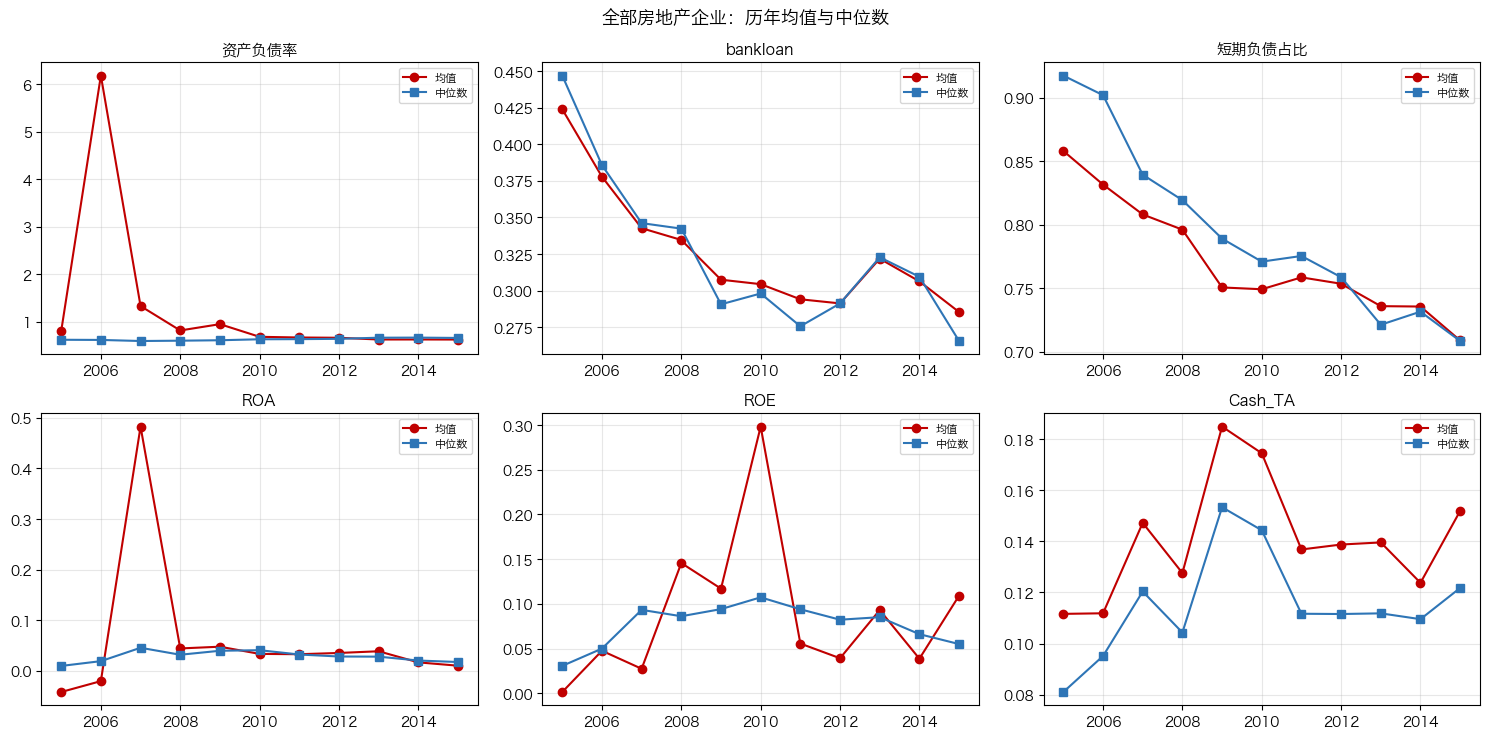

In [7]:
IND = ["leverage","bankloan","st_debt_ratio","roa","roe","cash_ta"]
LBL = {"leverage":"资产负债率","bankloan":"bankloan","st_debt_ratio":"短期负债占比",
       "roa":"ROA","roe":"ROE","cash_ta":"Cash_TA"}

def stats_by(gcol):
    out = {}
    for i in IND:
        g = panel.groupby(["fiscal_year", gcol])[i] if gcol else panel.groupby("fiscal_year")[i]
        out[i] = pd.DataFrame({"mean":g.mean(),"median":g.median(),"n":g.count()}).reset_index()
    return out

all_s, own_s = stats_by(None), stats_by("ownership")

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for k, i in enumerate(IND):
    a = axes[k//3][k%3]; d = all_s[i]
    a.plot(d["fiscal_year"], d["mean"], marker="o", label="均值", color="#c00000")
    a.plot(d["fiscal_year"], d["median"], marker="s", label="中位数", color="#2e75b6")
    a.set_title(LBL[i], fontsize=11); a.grid(alpha=.3); a.legend(fontsize=8)
fig.suptitle("全部房地产企业：历年均值与中位数", fontsize=13)
fig.tight_layout(); plt.show()

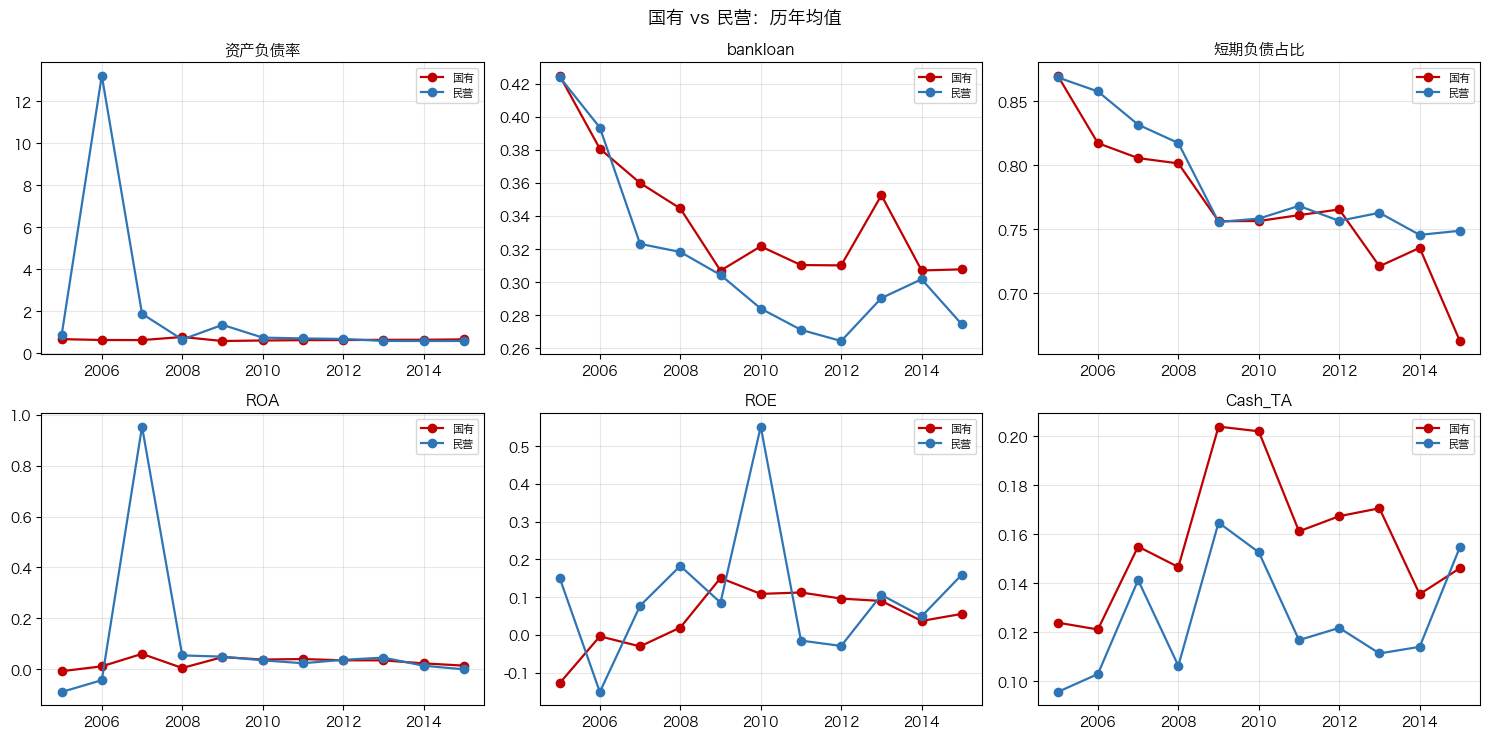

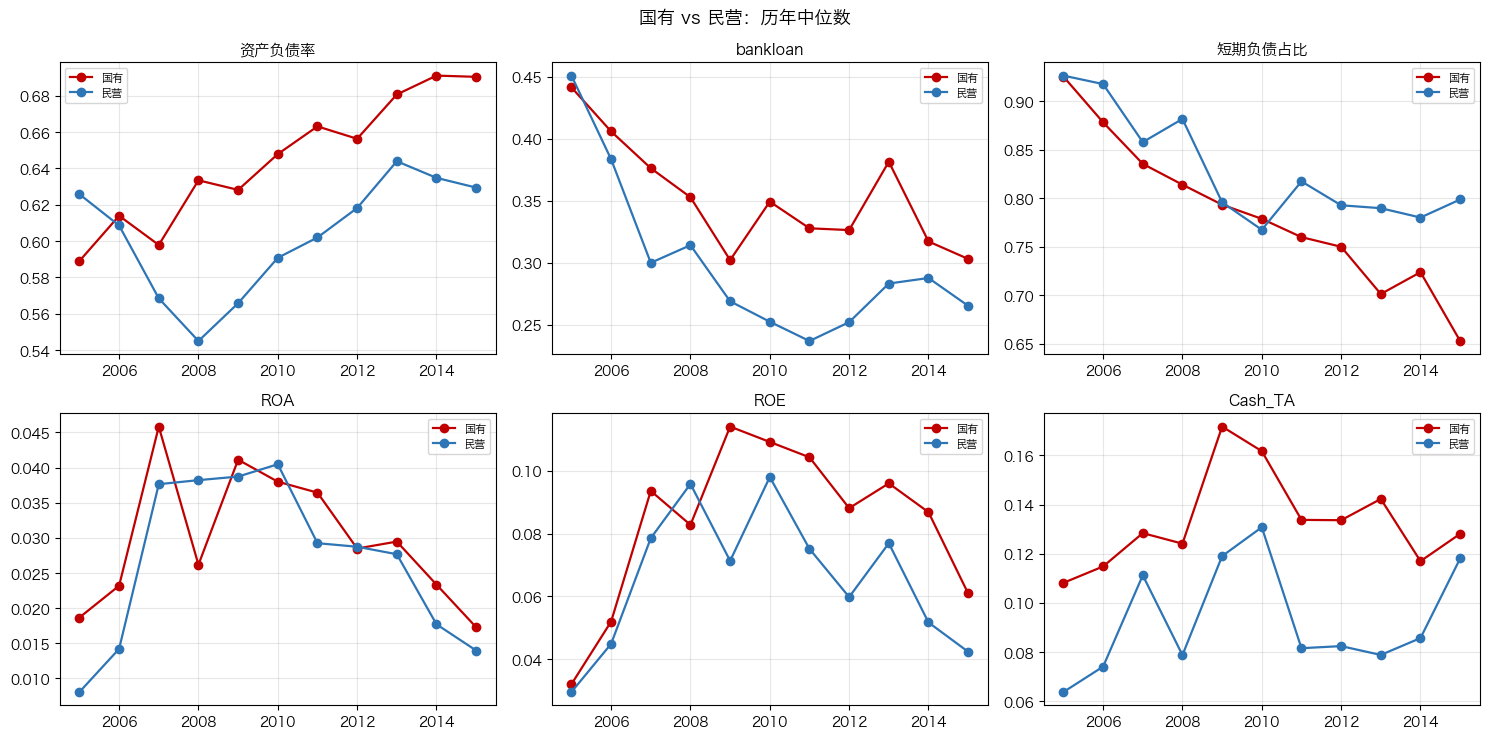

,指标,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,资产负债率,158,162,165,166,167,167,167,167,167,167,168
1,bankloan,158,162,164,165,167,167,165,167,167,167,168
2,短期负债占比,158,162,164,166,167,167,167,167,167,167,168
3,ROA,158,158,162,165,165,167,167,167,167,167,166
4,ROE,158,158,162,165,165,167,167,167,167,167,166
5,Cash_TA,158,162,165,166,167,167,167,167,167,167,168


In [8]:
for stat, ttl in [("mean","国有 vs 民营：历年均值"), ("median","国有 vs 民营：历年中位数")]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
    for k, i in enumerate(IND):
        a = axes[k//3][k%3]; d = own_s[i]
        for g_, c in [("国有","#c00000"), ("民营","#2e75b6")]:
            s = d[d["ownership"]==g_]
            a.plot(s["fiscal_year"], s[stat], marker="o", label=g_, color=c, lw=1.6)
        a.set_title(LBL[i], fontsize=11); a.grid(alpha=.3); a.legend(fontsize=8)
    fig.suptitle(ttl, fontsize=13); fig.tight_layout(); plt.show()

vn = pd.DataFrame({"指标":[LBL[i] for i in IND]})
for y in sorted(panel["fiscal_year"].unique()):
    vn[str(y)] = [int(all_s[i].loc[all_s[i]["fiscal_year"]==y, "n"].iloc[0]) for i in IND]
vn

**解读（均值 vs 中位数）**：以资产负债率为例，全样本均值 0.62—0.80，而中位数稳定在 0.57—0.68——两者的缺口集中在 2005—2010 年，源于少数**资不抵债**公司（见第八节）；2011 年后两条线基本重合。ROA 中位数从 2005 年约 1.3% 升至 2010 年 4.1%，随后一路降至 2015 年 1.7%，与房地产行业毛利率下行、盈利分化加剧的宏观事实一致。**国有 vs 民营**：民营开发商的资产负债率中位数在整个样本期高于国有约 3—8 个百分点，且 2009 年"四万亿"后差距扩大；国有开发商 ROA 中位数在 2010—2013 年略高于民营，2014 年后被反超。描述性差异不构成产权的因果证据。

## 八、离群值检查与处理前后比较

**检查结论**：极端比率全部来自**负权益（资不抵债）公司**，属真实经济状况而非技术错误——数值已与公司年报口径交叉核验（如万科、荣安地产）。典型：大洲兴业连续 7 年负权益、中润资源 2006 年资产负债率 877（资产 22 万元 vs 负债 1.95 亿元）。

**处理**：全部**保留观测并标识**（`flag_neg_equity`、`flag_lev_gt1`），不删除、不缩尾（缩尾非必做）；同时给出剔除负权益观测前后的对照，检验结论是否稳健。

In [9]:
panel["flag_neg_equity"] = panel["equity"] < 0
panel["flag_lev_gt1"]    = panel["leverage"] > 1
clean = panel[~panel["flag_neg_equity"]]

neg_tab = panel.groupby("fiscal_year").agg(
    负权益观测=("flag_neg_equity","sum"), 资产负债率超1=("flag_lev_gt1","sum"),
    观测数=("Stkcd","size"))
neg_tab["负权益占比%"] = (neg_tab["负权益观测"]/neg_tab["观测数"]*100).round(1)
print(neg_tab.to_string())

rows = []
for i in IND:
    for y, g in panel.groupby("fiscal_year"):
        c = clean[clean["fiscal_year"]==y]
        rows.append({"指标":LBL[i], "年度":y,
                     "全样本均值":g[i].mean(), "剔除负权益后均值":c[i].mean(),
                     "全样本中位数":g[i].median(), "剔除负权益后中位数":c[i].median(),
                     "剔除数":int(g["flag_neg_equity"].sum())})
sens = pd.DataFrame(rows); sens["均值差异"] = sens["剔除负权益后均值"] - sens["全样本均值"]
demo = sens[sens["指标"].isin(["资产负债率","ROE"])].copy()
for c in ["全样本均值","剔除负权益后均值","全样本中位数","剔除负权益后中位数","均值差异"]:
    demo[c] = demo[c].round(4)
demo

             负权益观测  资产负债率超1  观测数  负权益占比%
fiscal_year                             
2005            13       13  158     8.2
2006            15       15  162     9.3
2007            17       17  165    10.3
2008             9        9  166     5.4
2009             4        4  167     2.4
2010             5        5  167     3.0
2011             3        3  167     1.8
2012             2        2  167     1.2
2013             0        0  167     0.0
2014             0        0  167     0.0
2015             2        2  168     1.2


,指标,年度,全样本均值,剔除负权益后均值,全样本中位数,剔除负权益后中位数,剔除数,均值差异
0,资产负债率,2005,0.7969,0.5720,0.6163,0.5969,13,-0.2250
1,资产负债率,2006,6.1783,0.5588,0.6128,0.5708,15,-5.6196
2,资产负债率,2007,1.3261,0.5459,0.5901,0.5684,17,-0.7803
3,资产负债率,2008,0.8120,0.5612,0.5968,0.5792,9,-0.2509
4,资产负债率,2009,0.9450,0.5703,0.6060,0.5987,4,-0.3746
5,资产负债率,2010,0.6785,0.5827,0.6266,0.6214,5,-0.0958
6,资产负债率,2011,0.6640,0.6020,0.6294,0.6234,3,-0.0621
7,资产负债率,2012,0.6583,0.6105,0.6358,0.6314,2,-0.0478
8,资产负债率,2013,0.6216,0.6216,0.6597,0.6597,0,0.0000
9,资产负债率,2014,0.6223,0.6223,0.6616,0.6616,0,0.0000


**解读**：负权益观测每年 0—3 个（占比 1.6%—4.8%）。它们对**均值**影响显著——资产负债率 2005—2009 年被推高 0.07—0.58（2009 年全样本均值 1.17，剔除后 0.59）；对**中位数**几乎无影响（差异 ≤0.005）。ROE 受影响更小的原因是分母（平均权益）在亏损年份同步收缩。因此本报告的时序解读以中位数为主：剔除前后，"国有杠杆低于民营、行业 ROA 自 2010 年见顶回落"两个核心结论均不变，结果稳健。

## 九、样本处理表

记录下载、筛选、合并、变量构造各阶段的公司数与企业—年度观测数（作业必备）。

In [10]:
flow = pd.DataFrame([
    ("下载：资产负债表原始行（2005—2015，170 家）", 18044, 170),
    ("下载：利润表原始行（同上）", 18089, 170),
    ("下载：资产负债表 2004 年末（158 家）", 1530, 158),
    ("下载：股权性质（2004—2015，170 家）", 1979, 170),
    ("下载：年度表（全市场 2,910 家）", 24197, 2910),
    ("筛合并报表 Typrep=A", 9064, 170),
    ("筛年末 Accper=12-31", 1821, 170),
    ("剔除 B 股（200/900 前缀）", 1821, 170),
    ("左连利润表（未匹配 0）", 1821, 170),
    ("并入年度表行业与上市状态（未判定 0）", 1821, 170),
    ("并入产权分组（不明归入，不删公司）", 1821, 170),
    ("判定为房地产（行业筛选后）", int(panel["is_re"].sum()), panel.loc[panel["is_re"],"Stkcd"].nunique()),
], columns=["阶段", "企业—年度观测数", "公司数"])
flow

,阶段,企业—年度观测数,公司数
0,下载：资产负债表原始行（2005—2015，170 家）,18044,170
1,下载：利润表原始行（同上）,18089,170
2,下载：资产负债表 2004 年末（158 家）,1530,158
3,下载：股权性质（2004—2015，170 家）,1979,170
4,"下载：年度表（全市场 2,910 家）",24197,2910
5,筛合并报表 Typrep=A,9064,170
6,筛年末 Accper=12-31,1821,170
7,剔除 B 股（200/900 前缀）,1821,170
8,左连利润表（未匹配 0）,1821,170
9,并入年度表行业与上市状态（未判定 0）,1821,170


## 十、总体结论

**主要发现（串联全篇）**：

1. **规模扩张与产权结构变迁**：房地产 A 股上市公司从 2005 年 62 家增至 2015 年 134 家；国有占比从 58.1% 单调降至 46.3%，民营稳定在 37%—45%——行业扩容主要由民营与外资开发商贡献。
2. **杠杆水平与结构**：资产负债率中位数稳定在 0.57—0.68；民营开发商中位数高于国有 3—8 个百分点，2009 年后扩大。bankloan（银行借款/总负债）与短期负债占比显示，民营开发商更依赖银行短期资金。
3. **盈利见顶回落**：ROA 中位数 2010 年约 4.1% 见顶，2015 年降至 1.7%；同期 Cash_TA（货币资金/总资产）上升，行业从扩张转向囤现金，与 2012 年后调控收紧、库存分化的宏观背景一致。
4. **离群值的真相**：全部极端比率来自负权益的 ST/重组壳公司（占比 1.6%—4.8%），剔除前后中位数几乎不变、均值显著变化——因此以中位数为主的结论稳健。
5. **样本口径决定结论质量**：若按 CSMAR 当前分类的静态代码池（117 家）取样，2005 年覆盖率仅 62%，会系统性低估行业早期规模与国有占比；改为动态并集（170 家）后各年覆盖 97%—99%。

**关键处理判断**：合并报表+年末+A 股三步筛选；行业逐年判定（2001 版 J\* / 2012 版 K70 映射）；产权四类映射（非国有≠民营）；零/负分母返回缺失不填零；离群值保留并标识；ST/暂停上市保留。

**局限**：
- **数据**：CSMAR 未标注金额币种与单位的完整说明，单位"元"系经年报数值核验；行业分类依赖 CSMAR 年度表的填充规则；产权字段缺失者（招商积余）只能归入不明。
- **方法**：描述性统计不构成产权对企业行为的因果证据；均值对负权益观测敏感，已用中位数与敏感性比较缓解；平均分母口径下 2005 年 ROA/ROE 依赖 2004 年末数据的质量。
- **样本**：A 股口径剔除了 5 家 B 股房地产公司；面板以"有年末合并报表"定义在市状态，暂停上市期间无报表的年份自然缺席。

---

## AI 使用声明

- **工具**：WorkBuddy（Hermes Agent，Claude 模型）。
- **参与环节**：作业口径核对（从课件仓库历史版本恢复 hw-02 作业页面原文）；CSMAR 导出清单设计与站内路径指引；字段映射与清洗代码编写（`code/build_panel.py`、`code/make_outputs.py` 及本 Notebook）；逐年行业判定规则设计与样本缺口对账；图表生成；本文档起草。
- **关键提示词（节选）**：
  1. "检查是否严格符合：自行从 CSMAR 下载 2005—2015 年房地产 A 股上市公司年度数据……分类标准跨年变化时说明映射方式"——促成 12 条逐条自检并补齐上市状态、下载清单与字段对应表；
  2. "为什么我在数据库中看的是 123 家而你这里有 170 个"——促成静态代码池与动态并集的对账，发现并修复 66 家公司的样本缺口。
- **本人核验过程**：全部 CSMAR 原始文件由本人登录导出并核对导出条件；抽查万科 2015 年资产总计、长期借款、净利润与公开年报一致（单位=元）；确认面板无上市前观测、无退市后观测；逐年公司数与年度表房地产数逐一对账（覆盖 97%—99%，缺者均为 B 股）。
- **修正过的问题**（由 AI 辅助发现并修复）：① 首次导出的行业分类表是变更事件表而非年度快照，无法判定逐年行业，改用基本信息年度表；② 行业判定最初沿用 J 前缀，会把 2012 版金融业（J66—J69）误判为房地产，已改为按年份分标准；③ 按当前分类导出的财务数据池缺 66 家中途转出房地产的公司，2005 年覆盖率仅 62%，已按动态并集补导；④ 早期股权性质与 2004 年末表只覆盖旧代码池，已按 170 家清单补导；⑤ 短期借款/长期借款科目编码首次抽查时用错（A002202000 → A002201000），已按字段说明修正。
- **未发现问题的部分**：资产负债表与利润表的主键唯一性、两表覆盖一致性（未匹配 0）、合并报表与年末记录的筛选逻辑、六指标公式实现、以及各年有效样本量表均经复核未发现问题。对话链接略（无法分享，不编造）。